In [8]:
import os
os.makedirs('charts', exist_ok=True)

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('clean_master.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nChurn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")

Shape: (6001, 17)

Columns: ['customer_id', 'signup_date', 'age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_transactions', 'total_transaction_amount', 'last_transaction_date', 'total_tickets', 'high_risk_tickets', 'days_since_last_transaction', 'churn']

Churn Distribution:
churn
0    3750
1    2251
Name: count, dtype: int64

Churn Rate: 37.51%


In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
customer_id                        0
signup_date                     4508
age                                0
city                               0
acquisition_channel                0
employment_type                 1174
monthly_income                     0
active_lending_relationships       0
kyc_status                       241
primary_product                    0
total_transactions                 0
total_transaction_amount           0
last_transaction_date           1127
total_tickets                      0
high_risk_tickets                  0
days_since_last_transaction     1127
churn                              0
dtype: int64

Data Types:
customer_id                         str
signup_date                         str
age                             float64
city                                str
acquisition_channel                 str
employment_type                     str
monthly_income                  float64
active_lending_relationships      int64
kyc_statu

In [4]:
# Fix date columns
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_transaction_date'] = pd.to_datetime(df['last_transaction_date'], errors='coerce')

# Fix missing employment_type and kyc_status
df['employment_type'] = df['employment_type'].fillna('Unknown')
df['kyc_status'] = df['kyc_status'].fillna('Unknown')

# Confirm
print("Missing Values After Fix:")
print(df.isnull().sum())

Missing Values After Fix:
customer_id                        0
signup_date                     4508
age                                0
city                               0
acquisition_channel                0
employment_type                    0
monthly_income                     0
active_lending_relationships       0
kyc_status                         0
primary_product                    0
total_transactions                 0
total_transaction_amount           0
last_transaction_date           1127
total_tickets                      0
high_risk_tickets                  0
days_since_last_transaction     1127
churn                              0
dtype: int64


In [5]:
# Drop signup_date - too many unparseable formats, not a churn driver
df = df.drop(columns=['signup_date'])

# Fill missing transaction data with 0 for never-transacted customers
df['days_since_last_transaction'] = df['days_since_last_transaction'].fillna(999)
df['last_transaction_date'] = df['last_transaction_date'].fillna('Never')

# Final check
print("Missing Values After Final Fix:")
print(df.isnull().sum())
print(f"\nFinal Shape: {df.shape}")

Missing Values After Final Fix:
customer_id                     0
age                             0
city                            0
acquisition_channel             0
employment_type                 0
monthly_income                  0
active_lending_relationships    0
kyc_status                      0
primary_product                 0
total_transactions              0
total_transaction_amount        0
last_transaction_date           0
total_tickets                   0
high_risk_tickets               0
days_since_last_transaction     0
churn                           0
dtype: int64

Final Shape: (6001, 16)


In [6]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

C:\Users\Admin\AppData\Local\Temp\ipykernel_13096\4028386299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_channel.index, y=churn_by_channel.values, palette='Reds_r')


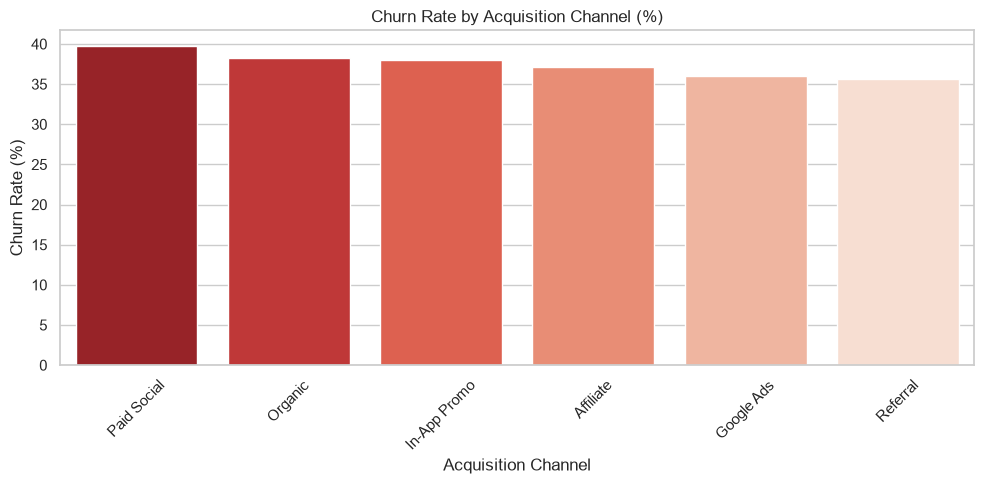

In [9]:
churn_by_channel = df.groupby('acquisition_channel')['churn'].mean().sort_values(ascending=False) * 100

plt.figure()
sns.barplot(x=churn_by_channel.index, y=churn_by_channel.values, palette='Reds_r')
plt.title('Churn Rate by Acquisition Channel (%)')
plt.xlabel('Acquisition Channel')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/churn_by_channel.png', dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13096\1637320632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_kyc.index, y=churn_by_kyc.values, palette='Oranges_r')


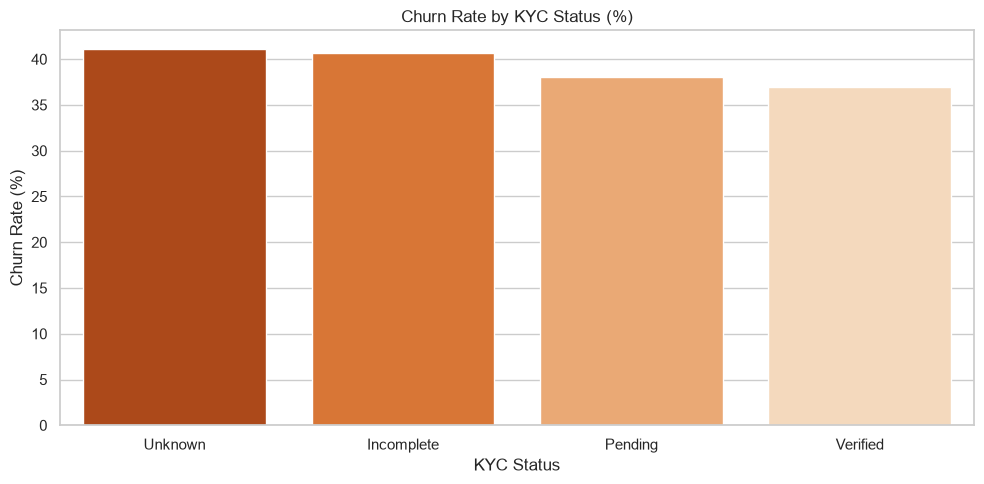

In [10]:
churn_by_kyc = df.groupby('kyc_status')['churn'].mean().sort_values(ascending=False) * 100

plt.figure()
sns.barplot(x=churn_by_kyc.index, y=churn_by_kyc.values, palette='Oranges_r')
plt.title('Churn Rate by KYC Status (%)')
plt.xlabel('KYC Status')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('charts/churn_by_kyc.png', dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13096\2539663532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_lending.index, y=churn_by_lending.values, palette='Reds_r')


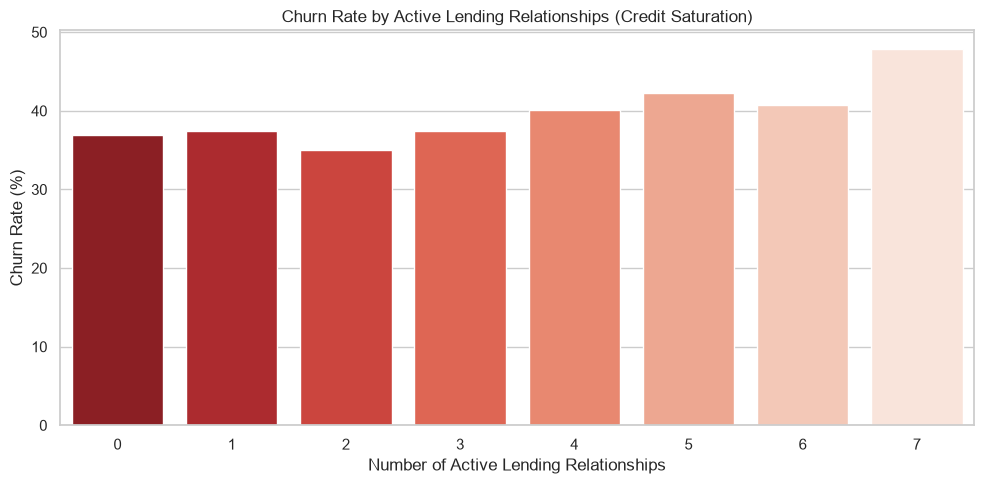

In [11]:
churn_by_lending = df.groupby('active_lending_relationships')['churn'].mean().sort_values(ascending=False) * 100

plt.figure()
sns.barplot(x=churn_by_lending.index, y=churn_by_lending.values, palette='Reds_r')
plt.title('Churn Rate by Active Lending Relationships (Credit Saturation)')
plt.xlabel('Number of Active Lending Relationships')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('charts/churn_by_lending.png', dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13096\3822919156.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_employment.index, y=churn_by_employment.values, palette='Blues_r')


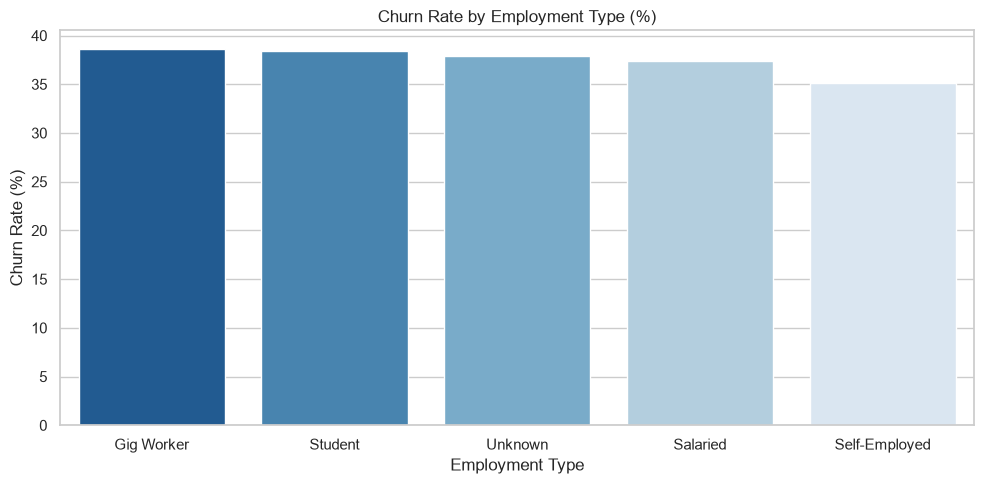

In [12]:
churn_by_employment = df.groupby('employment_type')['churn'].mean().sort_values(ascending=False) * 100

plt.figure()
sns.barplot(x=churn_by_employment.index, y=churn_by_employment.values, palette='Blues_r')
plt.title('Churn Rate by Employment Type (%)')
plt.xlabel('Employment Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('charts/churn_by_employment.png', dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13096\1436180349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='total_transactions', data=df, palette='Set2')


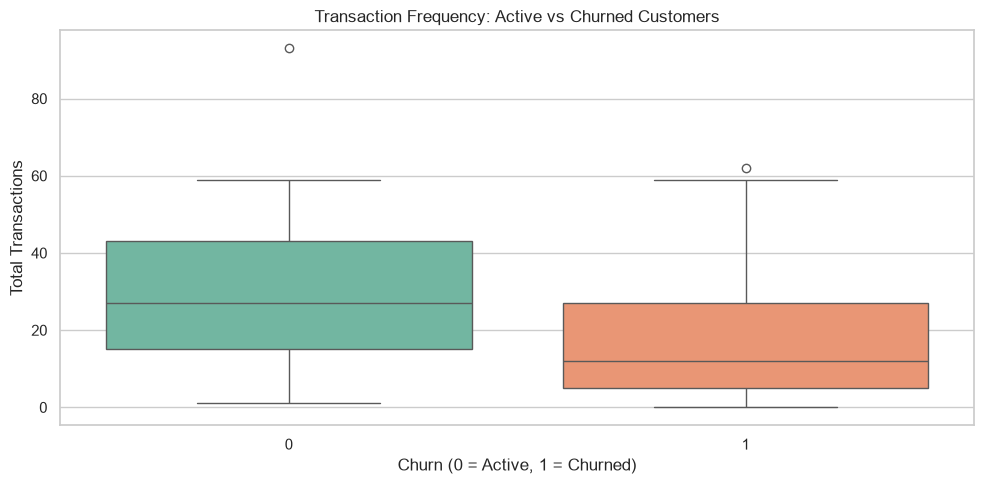

In [13]:
plt.figure()
sns.boxplot(x='churn', y='total_transactions', data=df, palette='Set2')
plt.title('Transaction Frequency: Active vs Churned Customers')
plt.xlabel('Churn (0 = Active, 1 = Churned)')
plt.ylabel('Total Transactions')
plt.tight_layout()
plt.savefig('charts/churn_by_transactions.png', dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13096\3159414533.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Active (0)', 'Churned (1)'], y=churn_by_tickets.values, palette='Set2')


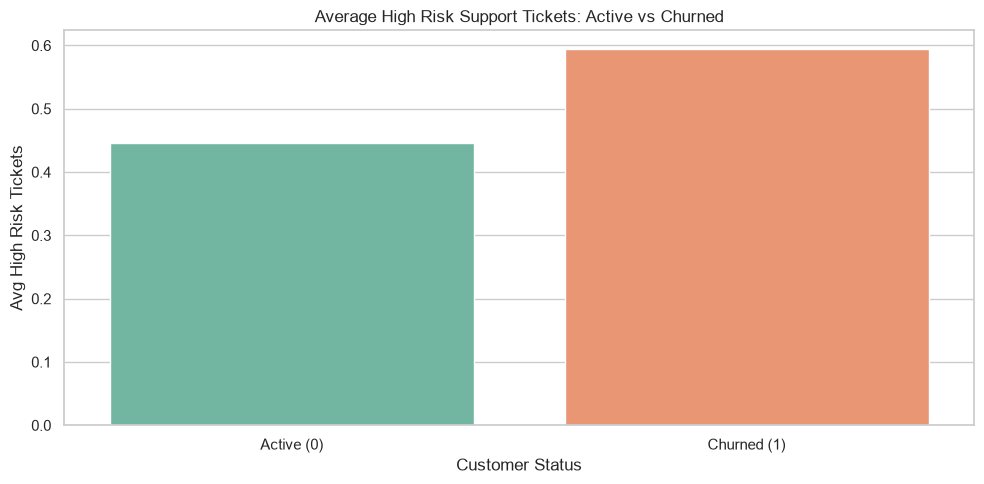

In [14]:
churn_by_tickets = df.groupby('churn')['high_risk_tickets'].mean()

plt.figure()
sns.barplot(x=['Active (0)', 'Churned (1)'], y=churn_by_tickets.values, palette='Set2')
plt.title('Average High Risk Support Tickets: Active vs Churned')
plt.xlabel('Customer Status')
plt.ylabel('Avg High Risk Tickets')
plt.tight_layout()
plt.savefig('charts/churn_by_tickets.png', dpi=150)
plt.show()

In [3]:
df = pd.read_csv('clean_master.csv')
print(df.columns.tolist())

['customer_id', 'signup_date', 'age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_transactions', 'total_transaction_amount', 'last_transaction_date', 'total_tickets', 'high_risk_tickets', 'days_since_last_transaction', 'churn']


## EDA vs Model Feature Importance — Reconciliation

The EDA identified acquisition channel, KYC status, and credit saturation 
as churn drivers based on group-level average differences:
- Paid Social: 40% churn vs Referral: 35.5% (4.5pp difference)
- Incomplete KYC: 41% churn vs Verified: 37% (4pp difference)
- 5+ lending relationships: 48% churn vs 0-2: 35% (13pp difference)

However, the Random Forest model assigned near-zero importance to these 
same features (0.01-0.02).

**Why this happens — and which to believe:**

EDA measures marginal differences between groups in isolation.
The model evaluates each feature's contribution after accounting for ALL 
other features simultaneously.

When transaction recency (days_since_last_transaction) dominates at 0.67 
importance, the model correctly ignores weaker signals — not because they 
are meaningless, but because they add little predictive value once recency 
is already known.

**Conclusion:**
- EDA findings are valid for business segmentation and targeted campaigns
- Model feature importance is valid for prediction accuracy
- These serve different purposes — EDA guides WHO to target, 
  the model guides WHEN to intervene